In [1]:
import uproot,json,os
import ROOT
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import mplhep as hep
from scipy import stats
import itertools

In [2]:
import awkward as ak

In [3]:
hep.style.use("CMS")
matplotlib.rcParams['figure.figsize'] = (6, 5.5)
matplotlib.rcParams['figure.dpi'] = 100

In [4]:
def getXProjections(x_arr,y_arr,nMinProj=-1):
    xU = np.unique(x_arr)
    xVal     =[]     
    xProj    =[]
    xProj_err=[]
    for x in xU:
        mask= x_arr==x
        if np.sum(mask) < nMinProj:
            continue
        avg = np.average( y_arr[mask] )
        std = np.std( y_arr[mask] )
        xProj.append(avg)
        xProj_err.append(std)
        xVal.append(x)
    return {'x':np.array(xVal) , 'projection' : np.array(xProj) , 'stdev' : np.array(xProj_err) }

In [5]:
# len(compressionRawEtMap)

In [6]:
compressionNTTMap=np.array([0,0,0,0,0,0,1,1,1,1,1,2,2,2,2,2,3,3,3,3,3,
                         4,4,4,4,4,5,5,5,5,5,6,6,6,6,6,7,7,7,7,7,8
                         ,8,8,8,8,9,9,9,9,9,10,10,10,10,10,
                         11,11,11,11,11,12,12,12,12,12,13,13,13,13,13,
                         14,14,14,14,14,15,15,15,15,15,16,16,16,16,16,
                         17,17,17,17,17,18,18,18,18,18,19,19,19,19,19,
                         20,20,20,20,20,21,21,21,21,21,22,22,22,22,22,
                         23,23,23,23,23,24,24,24,24,24,25,25,25,25,25,
                         26,26,26,26,26,27,27,27,27,27,28,28,28,28,28,
                         29,29,29,29,29,30,30,30,30,30,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,
                         31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,31,])

compressionRawEtMap=np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,1, 1, 1, 2, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 
                              7, 7, 8, 8, 9, 9, 10, 10, 11, 11, 12, 12, 13, 13, 14, 14, 15, 15, 16, 16, 16, 17, 17, 
                              17, 18, 18, 18, 19, 19, 19, 20, 20, 20, 21,21, 21, 22, 22, 22, 22, 23, 23, 23, 23, 24, 
                              24, 24, 24, 25, 25, 25, 25, 25, 26, 26, 26,26, 26, 26, 27, 27, 27, 27, 27, 27, 27, 28, 
                              28, 28, 28, 28, 28, 28, 28, 28, 28, 29, 29,29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 
                              29, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30,30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 
                              30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,30, 30, 30, 30, 30, 30, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 
                              31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31, 31,
                              31, 31, 31, 31, 31, 31, 31, 31]
                            )

compressionEtaMap=np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 
                            2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 
                            3, 3, 3, 3, 3, 3, 3, 3]
)

In [7]:
isolationFname='LUT_0p7_17_30.txt'

with open(isolationFname) as f:
    txt=f.readlines()

idx=0
isoLUT=[]
for l in txt:
    if len(l) <2 : continue
    if l.startswith('#') : continue
    l=l.split('#')[0].strip().split()
    index=int(l[0])
    if index!=idx:
        print(f"LUT not proper ! for expected index {idx} , the value obtained is {index}")
        raise ValueError
    isoLUT.append(int(l[1]))
    idx+=1
isoLUT=np.array(isoLUT)        

In [8]:
prefix='/data_CMS/cms/amella/Run3_2025/'
# fname='/home/aravind/Documents/dumpX/L1Ntuple_9.root'
# fname='/home/aravind/Documents/dumpX/L1NTuple_EZB123_2025C_dcs260525__slimmed.root'
fname=prefix+'ZeroBias_2025C_392295.root'

In [9]:
saveFig=False

In [10]:
file= uproot.open(fname)

In [11]:
file.keys()

['ZeroBias;1', 'ZeroBias/triggerNames;1', 'ZeroBias/ZeroBias;1']

In [12]:
tree=file['ZeroBias/ZeroBias']

In [13]:
branches=[]
for i in tree.keys():
    if 'l1tEmu' in i :
        branches.append(i)
#     branches.append(i)

In [14]:
print(branches)

['l1tEmuPt', 'l1tEmuEta', 'l1tEmuPhi', 'l1tEmuQual', 'l1tEmuIso', 'l1tEmuNTT', 'l1tEmuHasEM', 'l1tEmuIsMerged', 'l1tEmuTowerIEta', 'l1tEmuTowerIPhi', 'l1tEmuRawEt', 'l1tEmuIsoEt', 'l1tEmuPtJet', 'l1tEmuEtaJet', 'l1tEmuPhiJet', 'l1tEmuQualJet', 'l1tEmuIsoJet', 'l1tEmuTowerIEtaJet', 'l1tEmuTowerIPhiJet', 'l1tEmuRawEtJet', 'l1tEmuSumType', 'l1tEmuSumEt', 'l1tEmuSumPhi', 'l1tEmuSumIEt', 'l1tEmuSumIPhi', 'l1tEmuEGPt', 'l1tEmuEGEta', 'l1tEmuEGPhi', 'l1tEmuEGQual', 'l1tEmuEGIso', 'l1tEmuEGNTT', 'l1tEmuEGTowerIEta', 'l1tEmuEGTowerIPhi', 'l1tEmuEGRawEt', 'l1tEmuEGIsoEt', 'l1tEmuMuPt', 'l1tEmuMuEta', 'l1tEmuMuPhi', 'l1tEmuMuQual']


In [15]:
data=tree.arrays(branches,entry_stop=100000)

In [16]:
N_EVTS=len(data)

In [17]:
dataStore={}

In [18]:
# data.fields

In [19]:
counts=ak.num(data.l1tEmuRawEt)

intRawEt = np.array(ak.flatten( data.l1tEmuRawEt))

intRawEt[ intRawEt > 255 ] =255
dataStore['l1tEmuRawEt'] = intRawEt
dataStore['compressedRawEt']=compressionRawEtMap[intRawEt]
data['compressedRawEt']=ak.unflatten(dataStore['compressedRawEt'],counts)

/tmp/ipykernel_2409442/695623786.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  intRawEt = np.array(ak.flatten( data.l1tEmuRawEt))


In [20]:
counts=ak.num(data.l1tEmuNTT)

intNTT = np.array(ak.flatten( data.l1tEmuNTT))

intNTT[ intNTT > 1023 ] =1023
dataStore['counts']=counts
dataStore['l1tEmuNTT']=intNTT
dataStore['compressedNTT']=compressionNTTMap[intNTT]
data['compressedNTT']=ak.unflatten(dataStore['compressedNTT'],counts)

/tmp/ipykernel_2409442/862736768.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  intNTT = np.array(ak.flatten( data.l1tEmuNTT))


In [21]:
counts=ak.num(data.l1tEmuTowerIEta)

intIEta = np.array(ak.flatten( data.l1tEmuTowerIEta))
# intIEta[ intIEta > 15 ] =15
dataStore['l1tEmuTowerIEta']=intIEta
cbis=np.abs(intIEta)
cbis[cbis>31]=31
dataStore['compressedIEta']=compressionEtaMap[cbis]
data['compressedIEta']=ak.unflatten(dataStore['compressedIEta'],counts)

/tmp/ipykernel_2409442/2824467725.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  intIEta = np.array(ak.flatten( data.l1tEmuTowerIEta))


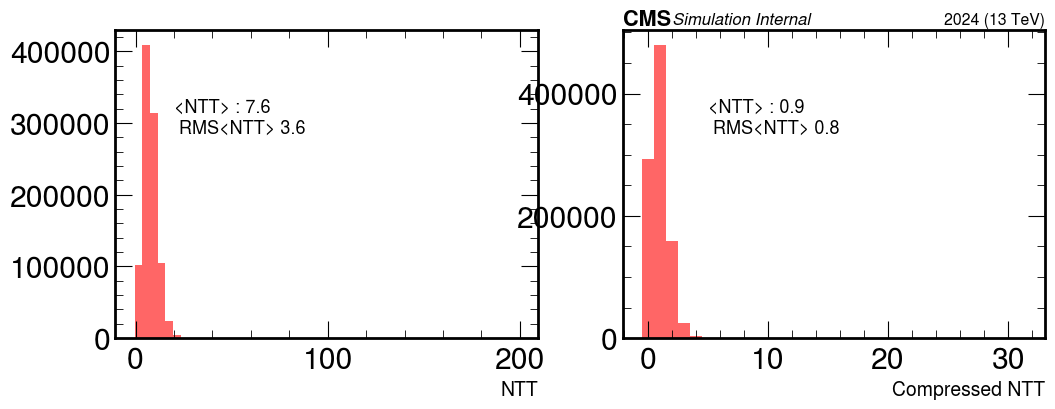

In [22]:
gMask=dataStore['l1tEmuNTT']>0
intNTT=np.array(dataStore['l1tEmuNTT'][gMask],dtype=int)

compressedNTT=dataStore['compressedNTT']

f,ax=plt.subplots(1,2,figsize=(12,4))

_=ax[0].hist(dataStore['l1tEmuNTT'][gMask],np.arange(-0.5,200.0,4),alpha=0.6,color='r')
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
mu=np.average(dataStore['l1tEmuNTT'][gMask])
stdev=np.std(dataStore['l1tEmuNTT'][gMask])
ax[0].text(20,max(_[0])*0.7,f"<NTT> : {mu:.1f}\n RMS<NTT> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('NTT',fontsize=14)
# hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])

_=ax[1].hist(compressedNTT,np.arange(-0.5,32.0,1),alpha=0.6,color='r')
mu=np.average(compressedNTT)
stdev=np.std(compressedNTT)
ax[1].text(5,max(_[0])*0.7,f"<NTT> : {mu:.1f}\n RMS<NTT> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('Compressed NTT',fontsize=14)
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[1])
if saveFig:
    plt.savefig(f'{prefix}/compressedNTT.png',bbox_inches='tight')
# plt.semilogy()

In [23]:
dataStore['l1tEmuIsoEt']=ak.flatten(data['l1tEmuIsoEt'])

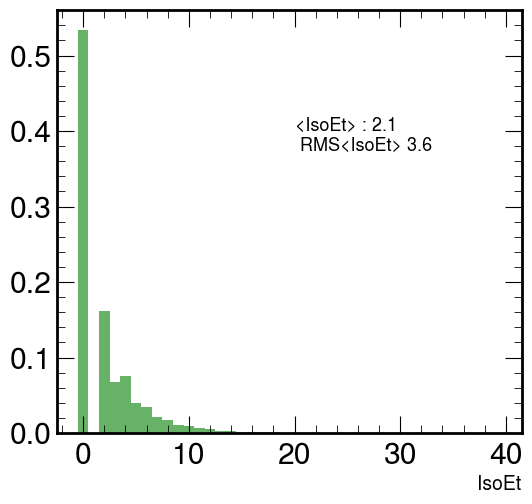

In [24]:
_=plt.hist(dataStore['l1tEmuIsoEt'],np.arange(-0.5,40.0,1),alpha=0.6,color='g',density=True)
mu=np.average(dataStore['l1tEmuIsoEt'])
stdev=np.std(dataStore['l1tEmuIsoEt'])
plt.text(20,max(_[0])*0.7,f"<IsoEt> : {mu:.1f}\n RMS<IsoEt> {stdev:.1f}",fontsize=13)
plt.xlabel('IsoEt',fontsize=14)
# hep.cms.label('Internal',fontsize=12,data=False,year='2024')
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/IsoEt.png',bbox_inches='tight')

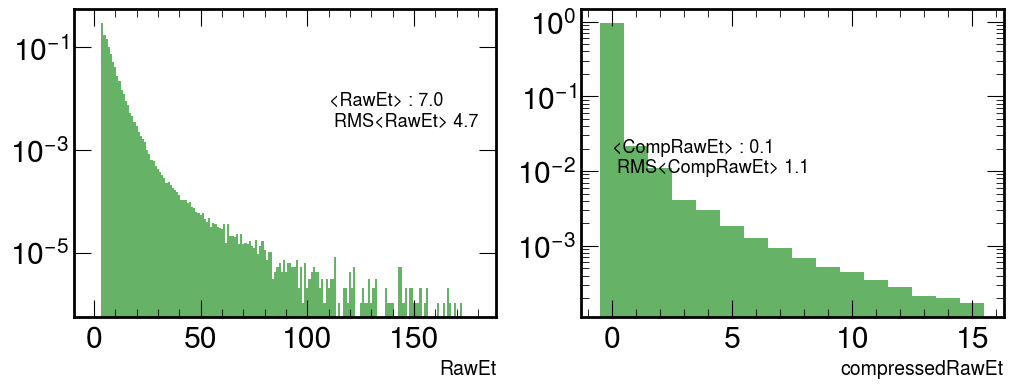

In [25]:
f,ax=plt.subplots(1,2,figsize=(12,4))

_=ax[0].hist(dataStore['l1tEmuRawEt'],np.arange(-0.5,180.0,1),alpha=0.6,color='g',density=True)
mu=np.average(dataStore['l1tEmuRawEt'])
stdev=np.std(dataStore['l1tEmuRawEt'])
ax[0].text(110,max(_[0])*0.01,f"<RawEt> : {mu:.1f}\n RMS<RawEt> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('RawEt',fontsize=14)
# hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])


_=ax[1].hist(dataStore['compressedRawEt'],np.arange(-0.5,16.0,1),alpha=0.6,color='g',density=True)
mu=np.average(dataStore['compressedRawEt'])
stdev=np.std(dataStore['compressedRawEt'])
ax[1].text(0,max(_[0])*0.01,f"<CompRawEt> : {mu:.1f}\n RMS<CompRawEt> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('compressedRawEt',fontsize=14)
# hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])
ax[0].semilogy()
ax[1].semilogy()
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/compressedRawEt.png',bbox_inches='tight')

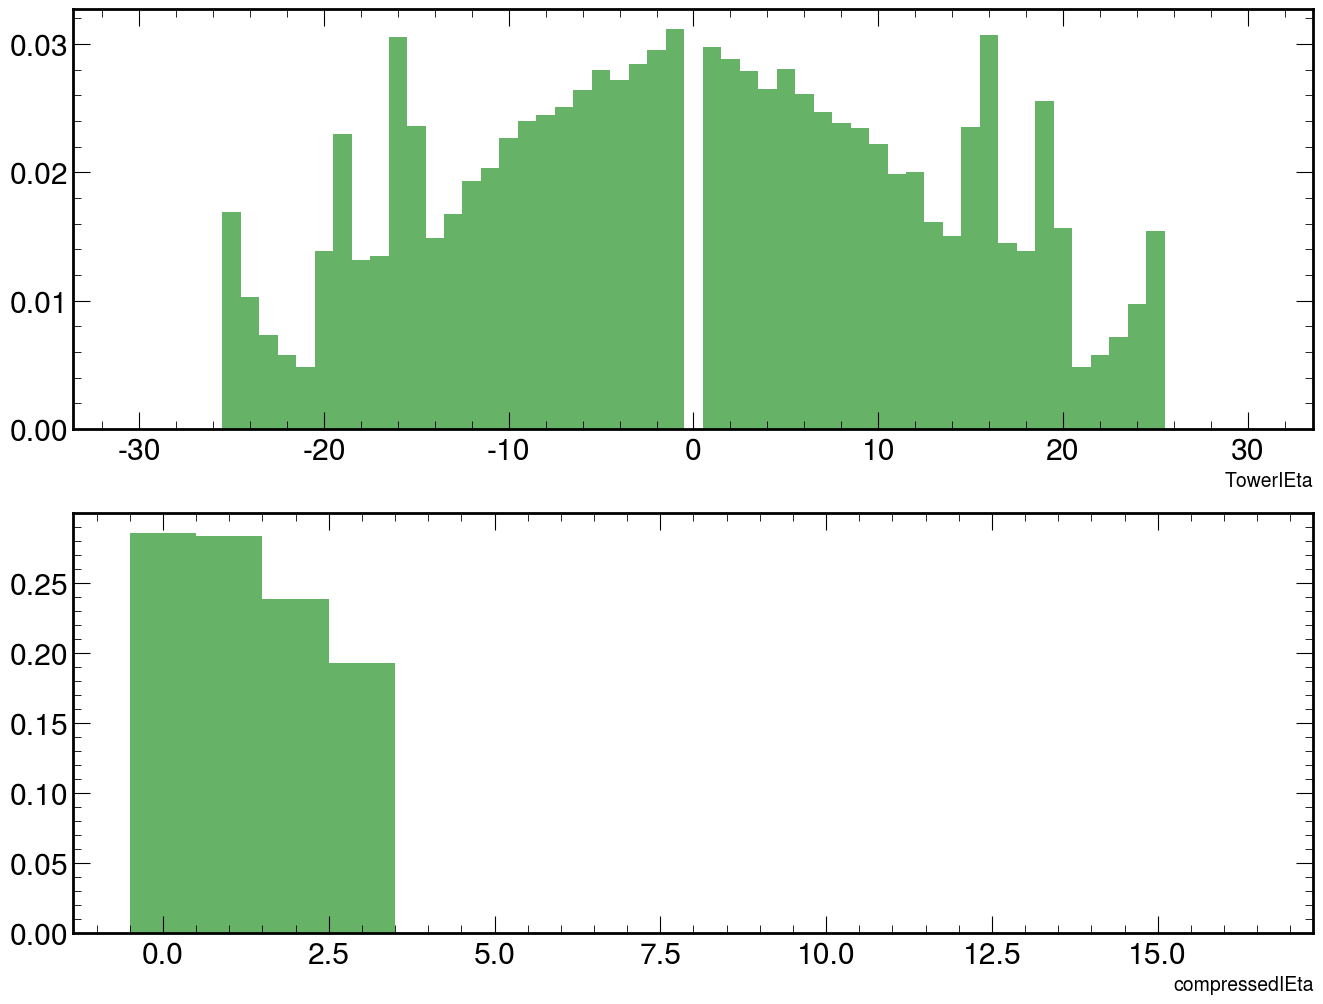

In [26]:
f,ax=plt.subplots(2,1,figsize=(16,12))
mask= np.abs(dataStore['l1tEmuTowerIEta']) < 32
_=ax[0].hist(dataStore['l1tEmuTowerIEta'][mask],np.arange(-30.5,31.0,1),alpha=0.6,color='g',density=True)
# mu=np.average(dataStore['l1tEmuEta'])
# stdev=np.std(dataStore['l1tEmuEta'])
# plt.text(110,max(_[0])*0.7,f"<l1tEmuEta> : {mu:.1f}\n RMS<l1tEmuEta> {stdev:.1f}",fontsize=13)
ax[0].set_xlabel('TowerIEta',fontsize=14)
# hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[0])

_=ax[1].hist(dataStore['compressedIEta'][mask],np.arange(-0.5,17.0,1),alpha=0.6,color='g',density=True)
# mu=np.average(dataStore['l1tEmuEta'])
# stdev=np.std(dataStore['l1tEmuEta'])
# plt.text(110,max(_[0])*0.7,f"<l1tEmuEta> : {mu:.1f}\n RMS<l1tEmuEta> {stdev:.1f}",fontsize=13)
ax[1].set_xlabel('compressedIEta',fontsize=14)
# hep.cms.label('Internal',fontsize=12,data=False,year='2024',ax=ax[1])
# hep.cms.label('Internal',fontsize=18,data=True,year='2023 C',lumi=9.7)
if saveFig:
    plt.savefig(f'{prefix}/compressedIEta.png',bbox_inches='tight')

In [27]:
isolationFname='LUT_0p7_17_30.txt'

with open(isolationFname) as f:
    txt=f.readlines()

idx=0
isoLUT=[]
for l in txt:
    if len(l) <2 : continue
    if l.startswith('#') : continue
    l=l.split('#')[0].strip().split()
    index=int(l[0])
    if index!=idx:
        print(f"LUT not proper ! for expected index {idx} , the value obtained is {index}")
        raise ValueError
    isoLUT.append(int(l[1]))
    idx+=1
isoLUT=np.array(isoLUT)        

In [28]:
ieta=dataStore['compressedIEta']
iet =dataStore['compressedRawEt']
intt=dataStore['compressedNTT']

lut_index = ieta<<10 | iet <<5 | intt

In [29]:
isolation_thr = isoLUT[lut_index]

In [30]:
dataStore['isolation_bit'] = dataStore['l1tEmuIsoEt'] < isolation_thr 

In [31]:
data['is_iso'] = ak.unflatten(dataStore['isolation_bit'],dataStore['counts'])

In [32]:
iso_leg = data['is_iso'] & ( data['l1tEmuRawEt'] > 0.0 )

In [33]:
rates=[]

In [34]:
ak.sum(ak.sum(iso_leg,axis=1) > 0)

np.int64(99977)

In [35]:
def singleIEtSeed(data,iet):
    seed_cond=  data['l1tEmuPt'] >= iet
    return ak.sum(seed_cond,axis=1) > 0

def singleIEtIsoSeed(data,iet):
    seed_cond = data['is_iso'] & (data['l1tEmuPt'] >= iet)
    return ak.sum(seed_cond,axis=1) > 0


def doubleIEtSeed(data,iet1,iet2):
    ltau1 = data['l1tEmuPt'] >= iet1
    leg2 = data['l1tEmuPt'] >= iet2
    nSeedPass= ( ak.sum(leg1,axis=1) > 0) & ( ak.sum(leg2,axis=1) > 1)
    return nSeedPass

def doubleIEtSingleIsoSeed(data,iet1,iet2):
    leg1 = (data['l1tEmuPt'] >= iet1) & data['is_iso']
    leg2 = (data['l1tEmuPt'] >= iet2) 
    nSeedPass= ( ak.sum(leg1,axis=1) > 0) & ( ak.sum(leg2,axis=1) > 1)
    return nSeedPass

def doubleIEtDoubelIsoSeed(data,iet1,iet2):
    leg1 = (data['l1tEmuPt'] >= iet1) & data['is_iso']
    leg2 = (data['l1tEmuPt'] >= iet2) & data['is_iso']
    nSeedPass= ( ak.sum(leg1,axis=1) > 0) & ( ak.sum(leg2,axis=1) > 1)
    return nSeedPass

all_seeds_to_probe={}
all_seeds_to_probe['Single']={}
all_seeds_to_probe['Double']={}

all_seeds_to_probe['Single']['SigleEG']=singleIEtSeed
all_seeds_to_probe['Single']['SingleIsoEG']=singleIEtIsoSeed

all_seeds_to_probe['Double']['DoubleEG']=doubleIEtSeed
all_seeds_to_probe['Double']['DoubleEGSingleIso']=doubleIEtSingleIsoSeed
all_seeds_to_probe['Double']['DoubleIsoEG']=doubleIEtDoubelIsoSeed

In [36]:
leg1 = data['l1tEmuPt'] >= 8
leg2 = data['l1tEmuPt'] >= 8

In [37]:
nSeedPass= ( ak.sum(leg1,axis=1) > 0) & ( ak.sum(leg2,axis=1) > 1)

In [38]:
np.where(nSeedPass)

(<Array [0, 6, 8, 13, 16, ..., 99993, 99994, 99995, 99997] type='44892 * int64'>,)

In [39]:
idx=2
print(np.array(leg1[idx]))
print(np.array(leg2[idx]))
print(nSeedPass[idx])
print(np.array(data[idx]['l1tEmuPt']))

[False False False False False False False False False False False False]
[False False False False False False False False False False False False]
False
[5.000001 4.000001 4.000001 3.000001 3.000001 3.000001 7.500001 5.500001
 5.500001 5.500001 4.000001 4.000001]


/tmp/ipykernel_2409442/2205310579.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(np.array(leg1[idx]))
/tmp/ipykernel_2409442/2205310579.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(np.array(leg2[idx]))
/tmp/ipykernel_2409442/2205310579.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide http

In [40]:
rate_scale_factor=26.5*1e3/N_EVTS

In [41]:
rateStore={}

In [42]:
rateStore['METADATA']={
    'RATE_SCALE' : rate_scale_factor
}

In [43]:
selector=all_seeds_to_probe['Single']['SigleEG']
rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
et_thr=[]
rates=[]
for i in range(81):
    print(f"\rDoing Et = {i}   ",end="")
    seed_events = selector(data,i)
    pass_count=int(ak.sum(seed_events))
    rateDict['pass'].append(pass_count)
    rateDict['rate'].append(pass_count*rate_scale_factor)
    rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
    rateDict['threashold'].append(i)
rateStore['SingleEG_Inclusive']=rateDict

Doing Et = 80   

In [44]:
rateStore.keys()

dict_keys(['METADATA', 'SingleEG_Inclusive'])

In [45]:
selector=all_seeds_to_probe['Single']['SingleIsoEG']
rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
et_thr=[]
rates=[]
for i in range(81):
    print(f"\rDoing Et = {i}   ",end="")
    seed_events = selector(data,i)
    pass_count=int(ak.sum(seed_events))
    rateDict['pass'].append(pass_count)
    rateDict['rate'].append(pass_count*rate_scale_factor)
    rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
    rateDict['threashold'].append(i)
rateStore['SingleEG_SingleIso']=rateDict

Doing Et = 80   

In [46]:
selector=all_seeds_to_probe['Double']['DoubleEG']
rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
et_thr=[]
rates=[]
for i in range(81):
    print(f"\rDoing Et = {i}   ",end="")
    seed_events = selector(data,i,i)
    pass_count=int(ak.sum(seed_events))
    rateDict['pass'].append(pass_count)
    rateDict['rate'].append(pass_count*rate_scale_factor)
    rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
    rateDict['threashold'].append(i)
rateStore['DoubleEG_Inclusive']=rateDict

Doing Et = 2   

Doing Et = 80   

In [47]:
selector=all_seeds_to_probe['Double']['DoubleIsoEG']
rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
et_thr=[]
rates=[]
for i in range(81):
    print(f"\rDoing Et = {i}   ",end="")
    seed_events = selector(data,i,i)
    pass_count=int(ak.sum(seed_events))
    rateDict['pass'].append(pass_count)
    rateDict['rate'].append(pass_count*rate_scale_factor)
    rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
    rateDict['threashold'].append(i)
rateStore['DoubleEG_DoubleIsoEG']=rateDict

Doing Et = 80   

In [48]:
selector=all_seeds_to_probe['Double']['DoubleEGSingleIso']
rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
et_thr=[]
rates=[]
for i in range(81):
    print(f"\rDoing Et = {i}   ",end="")
    seed_events = selector(data,i+10,i)
    pass_count=int(ak.sum(seed_events))
    rateDict['pass'].append(pass_count)
    rateDict['rate'].append(pass_count*rate_scale_factor)
    rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
    rateDict['threashold'].append(i)
rateStore['DoubleEGXandXp10_SingleIsoXplus10']=rateDict

Doing Et = 80   

In [49]:
# rateStore={}

# for selector_ky in selectorStore:
#     print("Making rates for  ",selector_ky)
#     selector=selectorStore[selector_ky]
#     rateDict={'threashold':[],'rate':[],'rate_err':[],'pass':[],'n_events':int(N_EVTS)}
#     et_thr=[]
#     rates=[]
#     for i in range(81):
#         print(f"\rDoing Et = {i}   ",end="")
#         seed_events = selector(data,i)
#         pass_count=int(ak.sum(seed_events))
#         rateDict['pass'].append(pass_count)
#         rateDict['rate'].append(pass_count*rate_scale_factor)
#         rateDict['rate_err'].append(pass_count**0.5*rate_scale_factor)
#         rateDict['threashold'].append(i)
#     rateStore[selector_ky]=rateDict
#     print()

In [50]:
from functools import partial

In [51]:
y= lambda x,y : doubleIEtSeed(x,y,y+10)

In [52]:
np.sum(doubleIEtSeed(data,10,10+10))

np.int64(1088)

In [53]:
np.sum(y(data,10))

np.int64(1088)

In [54]:
selectorStore={}
selectorStore['SingleEG_Inclusive'] = singleIEtSeed
selectorStore['SingleIsoEG'] = singleIEtIsoSeed
selectorStore['DoubleEG_Inclusive'] = lambda d,e1: doubleIEtSeed(d,e1,e1)
selectorStore['DoubleIsoEG'] = lambda d,e1: doubleIEtDoubelIsoSeed(d,e1,e1) 
selectorStore['DoubleEGXandXp10_SingleIsoXplus10'] = lambda d,e1: doubleIEtSingleIsoSeed(d,e1+10,e1)

SingleEG_Inclusive
[26495.23, 26495.23, 26495.23, 26495.23, 26392.41, 26077.06, 23933.210000000003, 22039.785, 19889.31, 17313.245000000003, 15010.925000000001, 12647.390000000001, 9119.975, 7708.85, 6442.945000000001, 5452.110000000001, 4592.9800000000005, 3314.6200000000003, 2853.255, 2449.6600000000003, 2098.005, 1789.8100000000002, 1574.895, 1252.39, 1115.915, 1009.9150000000001, 914.5150000000001, 835.015, 762.9350000000001, 648.19, 592.5400000000001, 512.775, 429.035, 354.305, 289.91, 255.72500000000002, 228.69500000000002, 199.81, 177.285, 154.495, 136.74, 124.81500000000001, 116.60000000000001, 107.855, 96.46000000000001, 91.16000000000001, 83.21000000000001, 77.38000000000001, 71.815, 65.455, 61.480000000000004, 55.915000000000006, 53.53, 49.29, 48.230000000000004, 45.050000000000004, 41.870000000000005, 40.545, 38.425000000000004, 37.1, 34.185, 32.065000000000005, 31.535, 30.740000000000002, 29.150000000000002, 27.825000000000003, 25.705000000000002, 24.91, 24.115000000000002

(exptext: Custom Text(0.001, 1, 'CMS'),
 expsuffix: Custom Text(0.001, 1.005, 'Internal'),
 supptext: Custom Text(1.012, 1, ''))

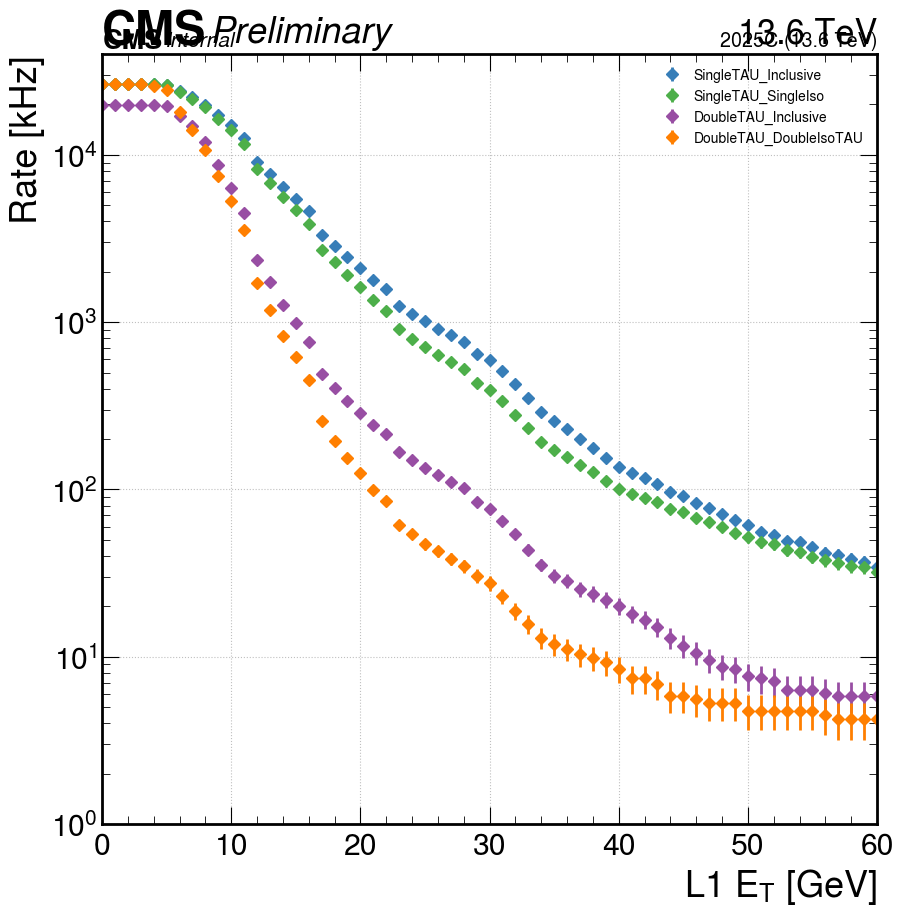

In [55]:
import mplhep
plt.style.use(mplhep.style.CMS)
mplhep.cms.label('Preliminary', data=True, rlabel=r'13.6 TeV')
cmap = matplotlib.colormaps.get_cmap('Set1')
for ky, color in zip(rateStore, [0,1,2,3,4]):
    if ky in ['METADATA'] :
            continue 
    print(ky)
    print(rateStore[ky]['rate'])
    plt.errorbar(rateStore[ky]['threashold'],
                 rateStore[ky]['rate'],
                 rateStore[ky]['rate_err'],
                 ls='None',
                 ecolor= cmap(color),
                 color= cmap(color),
                 label=ky.replace("EG","TAU"),
                 lw=2,
                 marker='D',
                #  markersize=3
                )
# plt.semilogy()
plt.grid(":") 
plt.ylim(1,4E4)
plt.legend(fontsize=10)
# plt.ylim([1,1e5])
plt.yscale('log')
plt.xlim([0,60])
# plt.axhline(14.0,color='k',alpha=0.4)
# plt.text(50.0,25,"14 kHz",fontsize=10)
# plt.axhline(4.0,color='k',alpha=0.4)
# plt.text(3.0,5,"4 kHz",fontsize=9)
plt.ylabel('Rate [kHz]')
plt.xlabel('L1 E$_{T}$ [GeV]')
hep.cms.label('Internal',data=True,year='2025C',fontsize=15,com=13.6)